# **Market Demand and Sales Analysis**

Analisis ini bertujuan untuk memahami pola permintaan penjualan pada e-commerce sales dataset melalui eksplorasi tren penjualan, distribusi produk, perilaku pembelian konsumen, serta faktor operasional yang mempengaruhi transaksi. Insight yang dihasilkan dari analisis ini digunakan sebagai dasar untuk memahami dinamika permintaan sebelum dilakukan proses demand forecasting.

Author: Sean Kafka Adhyaksa (Data Analyst)

---

# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

---

# **Data Loading**

In [2]:
# read csv
df = pd.read_csv('dataset/data_from_DE.csv')

In [3]:
# display DataFrame
df

,Status Pesanan,Waktu Pesanan Dibuat,Metode Pembayaran,Jumlah,Returned Quantity,Total Diskon,Total Berat,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Provinsi,Kategori Produk,Jenis Pembatalan,Alasan Pembatalan,Ekspedisi,Metode Pengiriman,Jumlah Terjual Bersih,Weekend
0,Selesai,2024-04-01 00:15:00,Saldo ShopeePay,1,0,0.0,1.00,0.0,10000.0,38300,10000.0,Banten,Home Organization & Living,NaN,NaN,SPX,Reguler,1,0
1,Selesai,2024-04-01 01:47:00,COD (Bayar di Tempat),1,0,0.0,0.50,0.0,14500.0,18576,14500.0,Jawa Tengah,Home Organization & Living,NaN,NaN,SPX,Hemat,1,0
2,Selesai,2024-04-01 04:25:00,SeaBank Bayar Instan,1,0,0.0,0.50,0.0,8000.0,7069,8000.0,Jawa Barat,Home Organization & Living,NaN,NaN,SPX,Hemat,1,0
3,Selesai,2024-04-01 04:41:00,COD (Bayar di Tempat),2,0,0.0,0.40,0.0,20000.0,32200,20000.0,Jambi,Kitchen & Dining,NaN,NaN,SPX,Hemat,2,0
4,Batal,2024-04-01 06:12:00,COD (Bayar di Tempat),1,0,0.0,1.20,0.0,0.0,0,8000.0,Banten,Other,Pembeli,Ubah Pesanan yang Ada,SPX,Hemat,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21578,Selesai,2025-09-30 21:30:00,Online Payment,2,0,0.0,0.20,0.0,3500.0,37500,3500.0,Jawa Barat,Tools & Accessories,NaN,NaN,SPX,Hemat,2,0
21579,Selesai,2025-09-30 21:35:00,COD (Bayar di Tempat),2,0,0.0,0.16,0.0,3500.0,15000,3500.0,Jawa Barat,Tools & Accessories,NaN,NaN,SPX,Hemat,2,0
21580,Selesai,2025-09-30 22:33:00,SPayLater,1,0,0.0,0.50,1000.0,15000.0,20000,16000.0,Lampung,Home Organization & Living,NaN,NaN,SPX,Hemat,1,0
21581,Selesai,2025-09-30 23:39:00,SPayLater,1,0,0.0,0.08,0.0,3500.0,9000,3500.0,Jawa Barat,Tools & Accessories,NaN,NaN,SPX,Hemat,1,0


Dataset ini terdiri dari 21583 row dengan 19 kolom berbeda.

Selain itu, kita melihat ada missing value `NaN` pada kolom seperti Jenis dan Alasan Pembatalan, kita akan bahas lebih lanjut sesaat lagi.

Melihat kolom `Weekend`, data terdiri dari hanya angka 0 yang tampak sama dari atas hingga bawah. Kita telusuri lebih dahulu unique values pada kolom tersebut.

In [4]:
# checking values of Weekend column
df['Weekend'].unique()

array([0, 1], dtype=int64)

Kolom `Weekend` menunjukkan makna boolean, di mana nilai 0 menunjukkan makna negasi *No*, yang artinya data transaksi dilakukan di luar hari weekend. Sebaliknya, nilai 1 berarti data tersebut terekam pada hari weekend.

Kita ubah angka 0 dan 1 dalam kolom tersebut menjadi kata *No* dan *Yes*.

In [5]:
# Convert to Yes No categorical boolean
df['Weekend'] = df['Weekend']\
    .replace({
        0: 'No',
        1: 'Yes'
        })

---

# **Data Understanding**

## **Overall Info**

In [6]:
# checking count and dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21583 entries, 0 to 21582
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Status Pesanan                      21583 non-null  object 
 1   Waktu Pesanan Dibuat                21583 non-null  object 
 2   Metode Pembayaran                   21583 non-null  object 
 3   Jumlah                              21583 non-null  int64  
 4   Returned Quantity                   21583 non-null  int64  
 5   Total Diskon                        21583 non-null  float64
 6   Total Berat                         21583 non-null  float64
 7   Ongkos Kirim Dibayar oleh Pembeli   21583 non-null  float64
 8   Estimasi Potongan Biaya Pengiriman  21583 non-null  float64
 9   Total Pembayaran                    21583 non-null  int64  
 10  Perkiraan Ongkos Kirim              21583 non-null  float64
 11  Provinsi                            21583

Dari 19 kolom yang ada, 9 di antaranya berisi nilai numerik (`float64` dan `int64`), adapun 10 yang lainnya berupa kategorikal (`object`). Kolom Jenis dan Alasan Pembatalan terindikasi memiliki missing values yang tampak dari jumlah `non-null` yang jauh lebih sedikit dibandingkan kolom lain.

Kita akan mengganti format kolom penanggalan `Waktu Pesanan Dibuat` menjadi dtype:datetime. Adapun kolom yang bermakna nilai uang yang masih berbentuk *float* akan diubah menjadi *interger*.

In [7]:
# temporal value to dtype:datetime
df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'])

# monetary value to dtype:int
cols = ['Total Diskon',
        'Ongkos Kirim Dibayar oleh Pembeli',
        'Estimasi Potongan Biaya Pengiriman',
        'Perkiraan Ongkos Kirim']

df[cols] = df[cols].astype('int64')

## **Any Duplicates?**

In [8]:
# checking duplicated rows
df.duplicated().sum()

716

Hasil pengecekan menunjukkan terdapat 716 baris yang terdeteksi sebagai data duplikat dalam dataset.

Namun, dalam konteks data transaksi penjualan seperti ini, baris yang tampaknya memiliki nilai yang sama persis bukan berarti menunjukkan kesalahan pencatatan. Perbedaan utama kemungkinan terdapat pada alamat pengiriman yang lebih spesifik, namun dalam dataset ini alamat hanya terobservasi hingga tingkat provinsi, sehingga beberapa transaksi dapat terlihat seolah-olah duplikat.

Oleh karena itu, data yang terindikasi duplikat tidak akan dieliminasi dan tetap dipertahankan dalam dataset, dan setiap baris akan diperlakukan sebagai record transaksi yang unik.

## **Any Missing Values?**

In [9]:
# checking missing values
mv = df.isnull().sum()
mv[mv > 0]

Jenis Pembatalan     18634
Alasan Pembatalan    18634
dtype: int64

Missing values pada kedua kolom Jenis dan Alasan Pembatalan ini bersifat *expected missing values* yang muncul secara logis. Hal ini karena ketika pesanan yang berhasil diselesaikan oleh pembeli, informasi dalam jenis dan alasan pembatalan memang akan hilang, dan sistem mencatat sebagai nilai kosong.

Oleh karena itu, nilai kosong tersebut tidak memerlukan perlakuan khusus seperti imputasi atau penghapusan data, dan tetap dibiarkan sebagaimana adanya karena tidak mempengaruhi analisis penjualan secara keseluruhan.

## **Inspecting Product Distribution**

Kategori Produk
Kitchen & Dining              7872
Home Organization & Living    7152
Tools & Accessories           3452
Food Storage & Packaging      1733
Other                          853
Bathroom & Cleaning            521
Name: count, dtype: int64

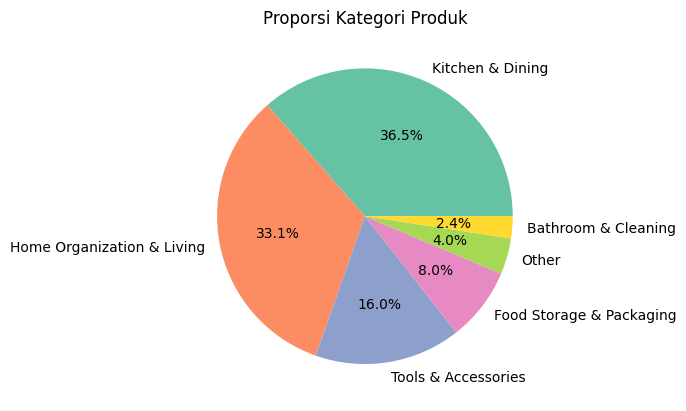

In [10]:
# counts of each product
product_count = df['Kategori Produk'].value_counts()
display(product_count)

# for color
colors = cm.Set2(range(len(product_count)))

# plot
plt.figure()
plt.pie(product_count, 
        labels=product_count.index, 
        autopct='%1.1f%%',
        colors=colors)
plt.title('Proporsi Kategori Produk')
plt.show()

Visualisasi distribusi ini menunjukkan data penjualan yang terkonsentrasi pada dua kategori utama, yaitu *Kitchen & Dining* (36.5%) dan *Home Organization & Living* (33.1%). Kedua kategori ini menyumbang hampir 70% dari total transaksi, menunjukkan bahwa sebagian besar permintaan berfokus pada produk kebutuhan rumah tangga, khususnya peralatan dapur dan perlengkapan penataan rumah.

Kategori `Tools & Accessories` berada di posisi berikutnya dengan angka sekitar 16%, sementara `Food Storage & Packaging` menyumbang sekitar 8% dari total penjualan. Di sisi lain, kategori `Other` (4%) dan `Bathroom & Cleaning` (2.4%) memiliki kontribusi yang relatif kecil sehingga tidak menjadi pendorong utama penjualan.

Secara keseluruhan, pola ini menunjukkan bahwa permintaan produk dalam dataset didominasi oleh beberapa kategori utama, dengan fokus yang kuat pada produk rumah tangga dan kebutuhan dapur.

## **Inspecting Categorical Columns**

In [11]:
pd.set_option('display.max_colwidth', None)

cat_cols = list(df.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, df[col].nunique(), df[col].unique()])

pd.DataFrame(columns=['Column Name', 'Unique Count', 'Unique Values'], data=listItem)

,Column Name,Unique Count,Unique Values
0,Status Pesanan,5,"[Selesai, Batal, Pesanan Diterima, Sedang Dikirim, Telah Dikirim]"
1,Metode Pembayaran,12,"[Saldo ShopeePay, COD (Bayar di Tempat), SeaBank Bayar Instan, SPayLater, Online Payment, Kartu Kredit/Debit, Indomaret/i.Saku, Alfamart/Alfamidi/Dan+Dan, Cicilan Kartu Kredit, BCA OneKlik, Pembayaran dibebaskan, Mitra Shopee]"
2,Provinsi,34,"[Banten, Jawa Tengah, Jawa Barat, Jambi, Riau, Lampung, Sulawesi Selatan, Bengkulu, Dki Jakarta, Jawa Timur, Sulawesi Utara, Kalimantan Tengah, Kalimantan Timur, Sumatera Utara, Sumatera Barat, Bangka Belitung, Sumatera Selatan, Kalimantan Barat, Kepulauan Riau, Nanggroe Aceh Darussalam (Nad), Di Yogyakarta, Kalimantan Selatan, Sulawesi Tengah, Maluku Utara, Bali, Nusa Tenggara Barat (Ntb), Gorontalo, Nusa Tenggara Timur (Ntt), Sulawesi Barat, Sulawesi Tenggara, Maluku, Kalimantan Utara, Papua, Papua Barat]"
3,Kategori Produk,6,"[Home Organization & Living, Kitchen & Dining, Other, Food Storage & Packaging, Bathroom & Cleaning, Tools & Accessories]"
4,Jenis Pembatalan,3,"[nan, Pembeli, Sistem Otomatis, Penjual]"
5,Alasan Pembatalan,15,"[nan, Ubah Pesanan yang Ada, Lainnya/ berubah pikiran, Pengiriman gagal, Penjual tidak mengatur pengiriman tepat waktu, Perlu mengubah alamat pengiriman, Lainnya, Penjual gagal mengirimkan pesanan tepat waktu, Perlu mengubah pesanan, Produk habis, Menemukan yang lebih murah, Penjual tidak responsif, Proses pembayaran sulit, Paket hilang di perjalanan, Perlu mengubah voucher, Tidak ingin membeli lagi]"
6,Ekspedisi,6,"[SPX, J&T, GrabExpress, JNE, Platform Default, GoSend]"
7,Metode Pengiriman,7,"[Reguler, Hemat, Instant Delivery, Pick Up Point, Same Day Delivery, Kargo, Express]"
8,Weekend,2,"[No, Yes]"


Terdapat 34 nama Provinsi di mana Nanggroe Aceh Darussalam, Nusa Tenggara Timur dan Barat memiliki nama singkat. Kita akan hapus nama singkat tersebut.

In [12]:
# removing (Nad), (Ntt), (Ntb) in Provinsi column
df['Provinsi'] = df['Provinsi'].str.replace(r'\(.*\)', '', regex=True).str.strip()

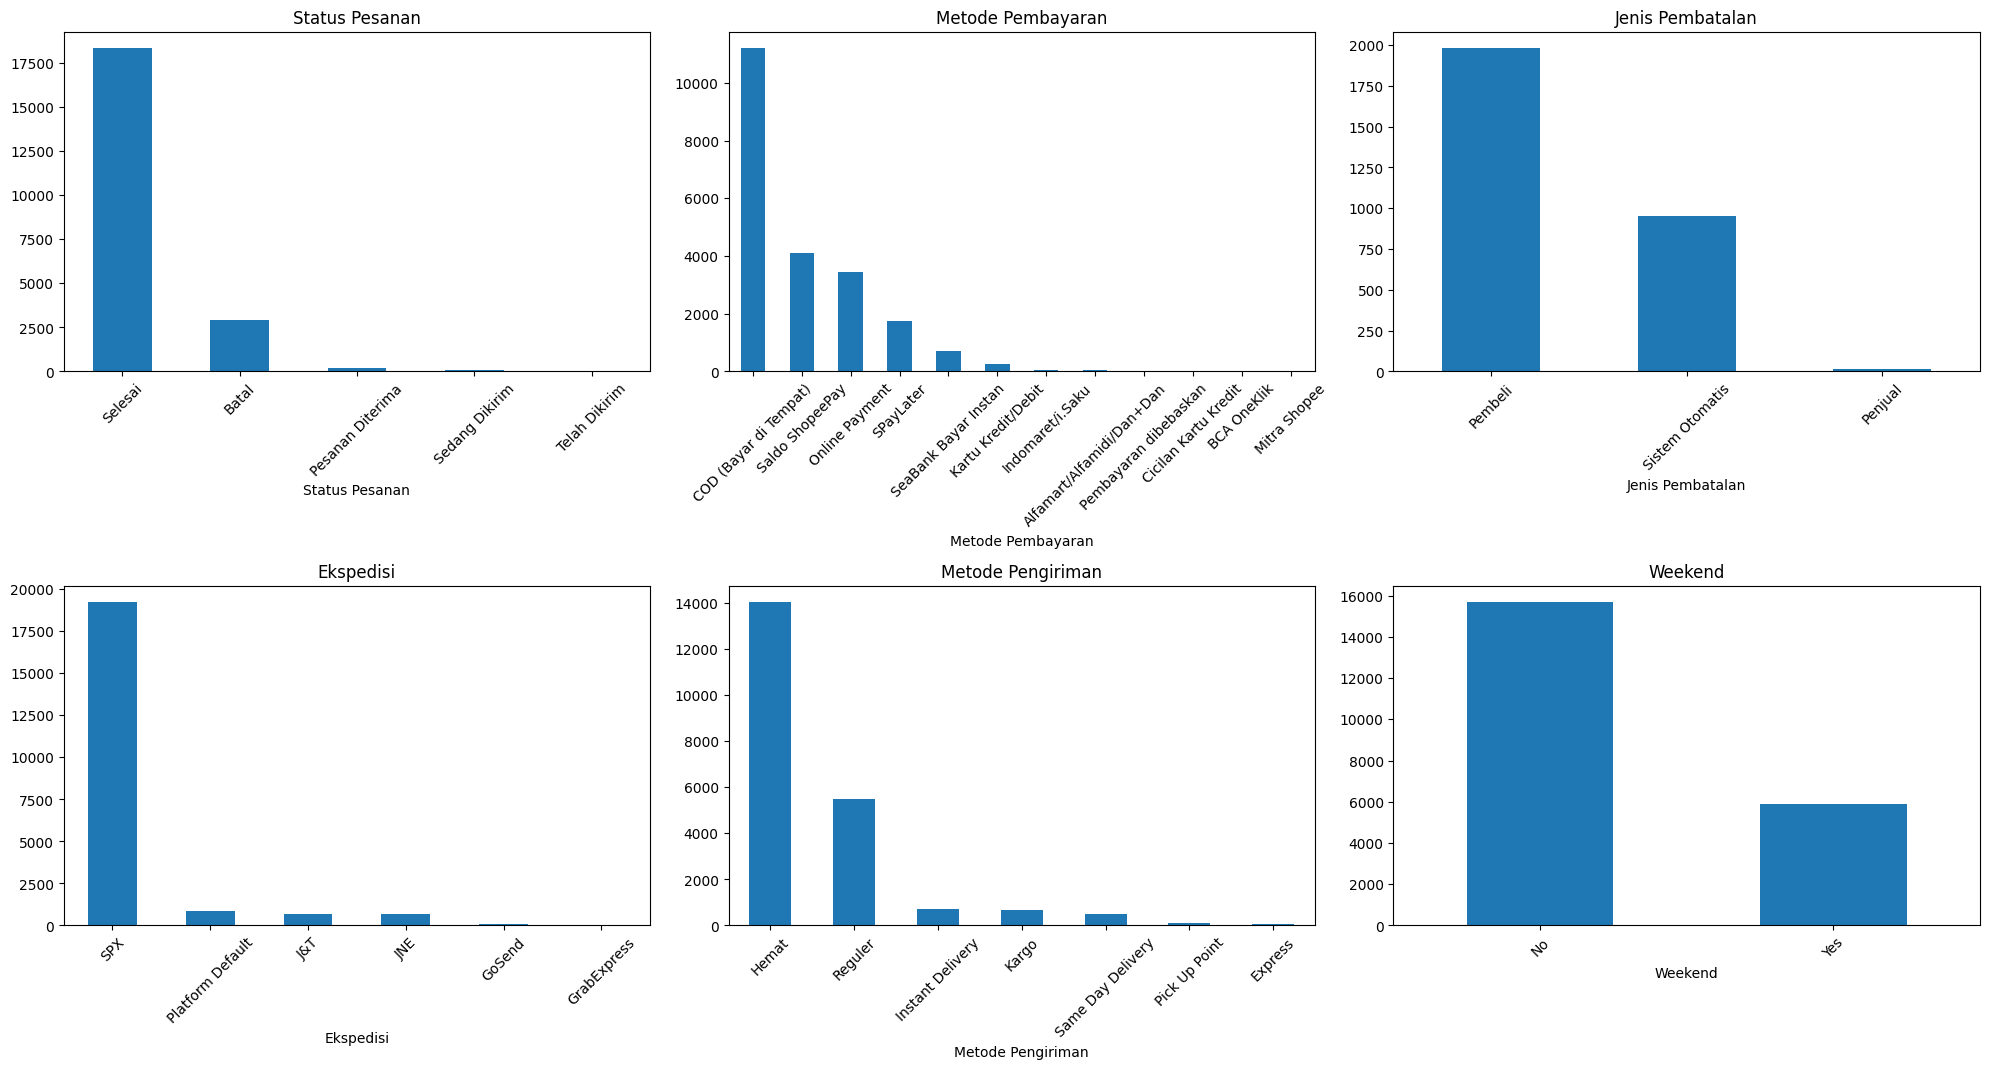

In [13]:
# select categorical columns
cat_cols = df.select_dtypes('object')\
    .drop(columns=['Kategori Produk',       # separate this target variable for its own vizualization
                   'Provinsi', 'Alasan Pembatalan']     # these two will have their own unique exploration
    ).columns

# visualize distribution
plt.figure(figsize=(20,15))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**1. Status Pesanan**  
Dari sisi `Status Pesanan`, terlihat bahwa hampir seluruh transaksi berakhir pada status *Selesai*, sementara jumlah pesanan yang berstatus *Batal* jauh lebih sedikit. Adapun status lain seperti *Pesanan Diterima* atau *Sedang Dikirim*  muncul dalam jumlah yang sangat kecil.

Pola ini menunjukkan bahwa sebagian besar order benar-benar sampai pada tahap pembelian yang selesai, bukan sekadar pesanan yang masih dalam proses.

**2. Metode Pembayaran**  
Melihat `Metode Pembayaran`, tampak bahwa *COD (Bayar di Tempat)* menunjukkan angka dominan dibanding metode lainnya. Metode pembayaran digital seperti *ShopeePay* dan *Online Payment* memang digunakan, tetapi jumlahnya masih jauh lebih kecil dibanding COD. 

Pola ini mengindikasikan bahwa sebagian besar pembeli masih lebih nyaman melakukan pembayaran ketika barang sudah sampai di tangan mereka, terutama untuk perkakas alat rumah tangga seperti yang ada dalam dataset ini. Kondisi ini juga mengindikasikan banyaknya konsumen yang belum sepenuhnya terbiasa menggunakan metode pembayaran digital.

**3. Pembatalan**  
Distribusi **Jenis Pembatalan** juga memberikan insight menarik mengenai perilaku konsumen. Sebagian besar pembatalan dilakukan oleh pembeli, sementara pembatalan oleh sistem otomatis jumlahnya lebih sedikit dan hampir tidak ada pembatalan yang berasal dari penjual.

Hal ini menunjukkan bahwa kegagalan transaksi lebih sering disebabkan oleh keputusan pembeli sendiri. Misalnya karena berubah pikiran setelah melakukan checkout, atau menemukan harga yang lebih murah di tempat lain. Pembatalan dalam dataset ini tampak lebih banyak berkaitan dengan perilaku konsumen dibanding masalah operasional penjual.

**4. Logistik**  
Dari sisi logistik, terlihat bahwa `Ekspedisi` *SPX* digunakan pada sebagian besar transaksi, jauh melampaui ekspedisi lain seperti *J&T* atau *JNE*. Dominasi ini kemungkinan besar terjadi karena integrasi ekspedisi internal marketplace yang biasanya menawarkan ongkos kirim yang lebih ekonomis.

Melihat pada `Metode Pengiriman`, mayoritas pembeli memilih opsi *Hemat*, sementara opsi seperti *Reguler*, *Instant Delivery*, atau *Same Day Delivery* digunakan jauh lebih sedikit. Pola ini mengindikasikan bahwa sebagian besar konsumen lebih memilih ongkir yang lebih murah daripada pengiriman barang yang cepat.

**5. Weekday & Weekend Sales**  
Terakhir, distribusi transaksi berdasarkan *weekday* dan *weekend* menunjukkan bahwa sebagian besar penjualan terjadi pada hari kerja. Jumlah transaksi pada hari libur memang ada, tetapi jauh lebih sedikit dibanding hari biasa. Pola ini bisa mengindikasikan bahwa pembeli kemungkinan besar melakukan aktivitas belanja saat sedang aktif pada device mereka saat rutinitas harian, misalnya saat bekerja.

Secara keseluruhan, distribusi kategori ini memberikan gambaran awal mengenai karakteristik transaksi dalam dataset. Insight awal ini penting karena membantu memahami perilaku dasar konsumen sebelum analisis lebih lanjut.

## **Inspecting Numeric Columns**

,Jumlah,Returned Quantity,Total Diskon,Total Berat,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Jumlah Terjual Bersih
count,21583.00,21583.00,21583.00,21583.00,21583.00,21583.00,21583.00,21583.00,21583.00
mean,2.10,0.04,459.46,1.54,8539.57,11140.55,54711.72,19297.00,2.06
std,6.91,1.13,11199.20,3.93,49926.88,12719.70,144072.57,23893.59,6.81
min,1.00,0.00,0.00,0.01,0.00,0.00,0.00,1000.00,0.00
25%,1.00,0.00,0.00,0.35,0.00,0.00,14563.00,8000.00,1.00
50%,1.00,0.00,0.00,0.50,0.00,9500.00,24296.00,13000.00,1.00
75%,2.00,0.00,0.00,1.20,4000.00,16000.00,48378.50,21000.00,2.00
max,256.00,100.00,700000.00,187.50,999000.00,312000.00,3076000.00,624000.00,256.00


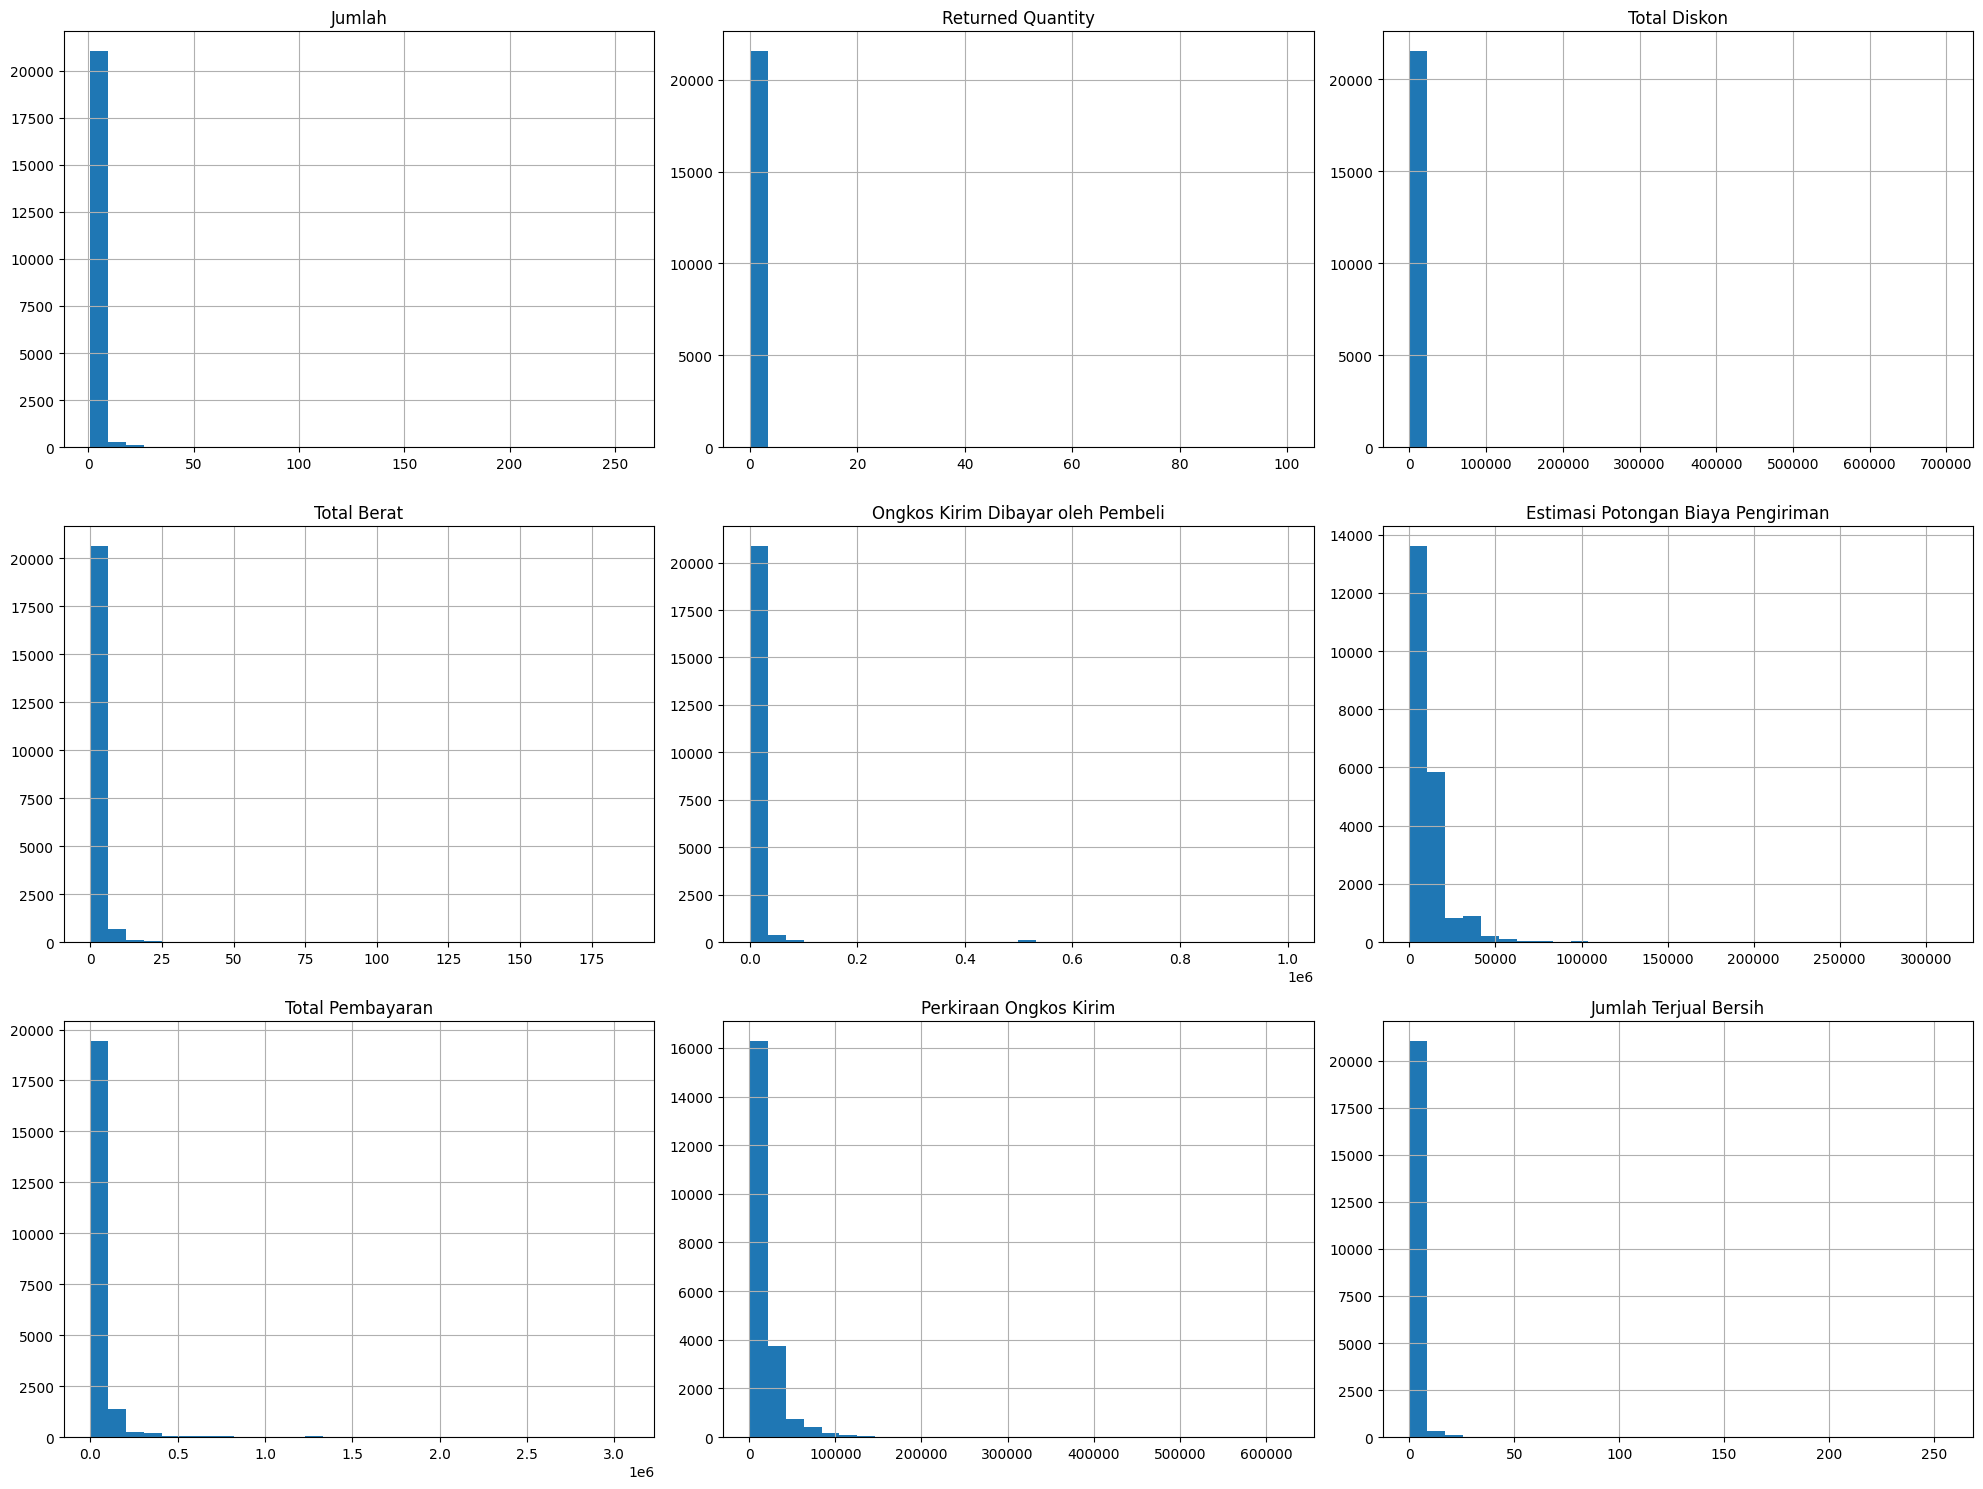

In [14]:
# descriptive stats, excluding datetime column
display(df
    .drop(columns='Waktu Pesanan Dibuat')
    .describe()
    .round(2)
    )

# select numeric columns
num_cols = df.select_dtypes(np.number).columns

# visualize distribution
df[num_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

**1. Jumlah Pesanan**  
Melihat kolom `Jumlah`, Nilai median (row *50%*) berada di sekitar satu unit dan kuartil ketiga (row *75%*) hanya mencapai dua unit, yang menunjukkan sebagian besar transaksi terdiri dari penjualan produk dalam jumlah kecil. Walaupun demikian, terdapat beberapa transaksi dengan jumlah yang jauh lebih besar hingga ratusan unit. Anomali ini kemungkinan berasal dari konsumen yang melakukan pembelian grosir untuk keperluan usaha.

Pola ini juga selaras dengan distribusi `Jumlah Terjual Bersih` yang merupakan jumlah barang yang berhasil terjual dikurangi barang retur (`Returned Quantity`).

Sebagian besar transaksi berhasil diterima oleh pembeli tanpa adanya pengembalian barang. Hal ini terlihat dari median dan kuartil atas yang berada di angka nol pada kolom `Returned quantity`. Oleh karena itu, nilai pada Jumlah Terjual Bersih pada umumnya tidak berbeda jauh dengan jumlah pesanan awal.

**2. Harga Diskon**  
Distribusi `Total Diskon` menunjukkan insight yang cukup menarik. Beberapa transaksi yang mendapatkan potongan harga sangat besar, namun sebagian besar transaksi justru tidak menggunakan diskon sama sekali. Hal tampak terlihat dari nilai kuartil pertama (row *25%*) hingga kuartil ketiga yang semuanya berada di angka nol.

Kondisi ini mengindikasikan bahwa diskon tidak selalu terjadi pada barang dengan harga satuan yang relatif murah. Diskon kemungkinan hanya diberikan pada periode event tertentu atau saat pembelian dalam jumlah besar.

**3. Biaya Logistik**
Dari kolom `Ongkos Kirim Dibayar oleh Pembeli`, terlihat bahwa sebagian besar pembeli tidak dibebankan biaya ongkir, terlihat dari nilai median dan kuartil awal berada di angka nol. Hal ini menunjukkan bahwa biaya logistik kemungkinan ditanggung oleh penjual atau melalui program gratis ongkir oleh perusahaan. Namun, perbedaan yang signifikan dari nilai ongkir mayoritas menunjukkan adanya variasi biaya pengiriman yang dipengaruhi oleh faktor jarak destinasi di berbagai provinsi di Indonesia, berat produk, atau metode pengiriman yang dipilih.

**4. Total Pembayaran (Net Revenue)**  
Kolom `Total Pembayaran` merupakan hasil perhitungan dari harga awal barang dikurangi harga diskon dan biaya logistik. Kolom ini juga menunjukkan net revenue yang didapatkan oleh perusahaan dalam dataset ini.

Sebagian besar transaksi berada pada nilai yang relatif kecil hingga menengah, sementara hanya sedikit transaksi dengan nilai yang sangat besar. Distribusi ini menghasilkan pola yang condong ke kanan (right-skewed). Artinya, sebagian besar pembelian terjadi pada nilai transaksi yang rendah, sementara transaksi bernilai sangat tinggi hanya terjadi dalam jumlah kecil.

---

# **Exploratory Data Analysis**

## **1. Monthly Sales Distribution**

Sebelum melakukan agregasi, kita harus akan kolom baru `year_month` dari kolom datetime `Waktu Pesanan Dibuat`. Hal ini diperlukan karena dataset ini awalnya masih berada pada level timestamp lengkap (tanggal dan waktu). Jika kita analisis langsung tanpa transformasi, agregasi akan menghasilkan banyak nilai unik per transaksi pada titik waktunya masing-masing.

In [15]:
# create year_month column
df['year_month'] = df['Waktu Pesanan Dibuat'].dt.to_period('M')

Setiap data lalu diagregasi berdasarkan waktu bulanan yang konsisten pada `year_month` sehingga total penjualan bisa dihitung per bulan. 
Kita memisahkan perhitungan agregasi terhadap 6 kategori produk yang berbeda, lalu divisualisasikan menggunakan area plot.

In [16]:
# agg month by Kategori Produk
monthly_category = (
    df.groupby(['year_month', 'Kategori Produk'])['Jumlah Terjual Bersih']
      .sum()
      .reset_index()
)

# change month as string 
monthly_category['year_month'] = monthly_category['year_month'].astype(str)

# pivot to wide format
pivot_df = monthly_category.pivot(
    index='year_month',
    columns='Kategori Produk',
    values='Jumlah Terjual Bersih'
).fillna(0)

<Figure size 1200x1200 with 0 Axes>

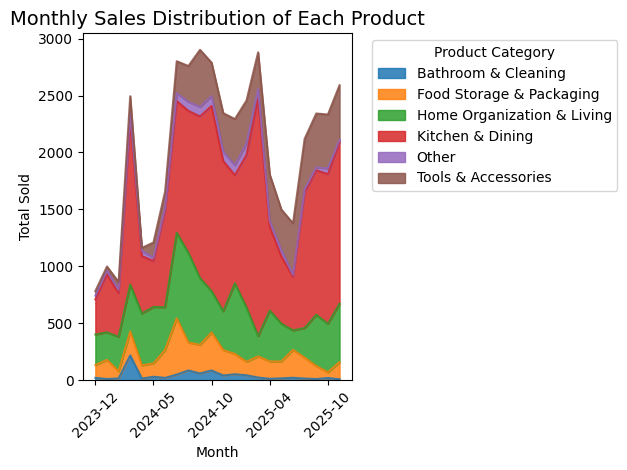

In [17]:
# visualize
plt.figure(figsize=(12,12))

pivot_df.plot(
    kind='area', 
    stacked=True, 
    alpha=0.85
)

plt.title('Monthly Sales Distribution of Each Product', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sold')
plt.xticks(rotation=45)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

Visualisasi menunjukkan bahwa pola penjualan bulanan didominasi oleh dua kategori utama, yaitu *Kitchen & Dining* dan *Home Organization & Living*, sama seperti pie chart sebelumnya saat pertama kali inspeksi.

Kedua kategori ini secara konsisten memberikan kontribusi terbesar terhadap total penjualan hampir di setiap bulan. Kategori *Tools & Accessories* juga terlihat memberikan kontribusi yang cukup stabil, meskipun volumenya masih berada di bawah dua kategori utama.

Sementara itu, kategori seperti *Food Storage & Packaging*, *Other*, dan *Bathroom & Cleaning* memiliki kontribusi yang relatif kecil terhadap total penjualan bulanan. Meski demikian, tiga kategori ini tetap menampilkan fluktuasi demand yang mengikuti pola total penjualan.

Kita coba lihat angka standard deviation untuk mengetahui variabilitas penjualan tiap produk. 

In [18]:
# variability of each product category
monthly_std = pivot_df.std().sort_values(ascending=False)
monthly_std

Kategori Produk
Kitchen & Dining              480.600805
Home Organization & Living    164.412558
Tools & Accessories           162.528799
Food Storage & Packaging       96.588351
Bathroom & Cleaning            45.832959
Other                          27.094711
dtype: float64

Diketahui *Kitchen & Dining* memiliki variabilitas paling tinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa permintaan pada produk ini mengalami perubahan yang cukup besar antar bulan.

Sementara itu, *Home Organization & Living* dan *Tools & Accessories* memiliki tingkat variabilitas yang relatif mirip di angka sekitar 160.

Adapun kategori *Food Storage & Packaging*, *Bathroom & Cleaning*, dan *Other* memiliki tingkat variabilitas yang lebih kecil lagi, mengindikasikan bahwa volume penjualan pada kategori tersebut relatif lebih stabil, tetapi kontribusi total penjualannya lebih kecil.

Secara keseluruhan, hasil ini memperkuat temuan pada visualisasi sebelumnya bahwa perubahan penjualan bulanan dalam dataset ini terutama dipengaruhi oleh kategori *Kitchen & Dining*, karena kategori ini memiliki volume penjualan terbesar dan juga tingkat fluktuasi permintaan yang paling tinggi.

## **2. Monthly Sales Trend and Growth**

In [19]:
monthly_total = (
    df.groupby('year_month')['Jumlah Terjual Bersih']
      .sum()
      .reset_index()
)

monthly_total['year_month'] = monthly_total['year_month'].astype(str)

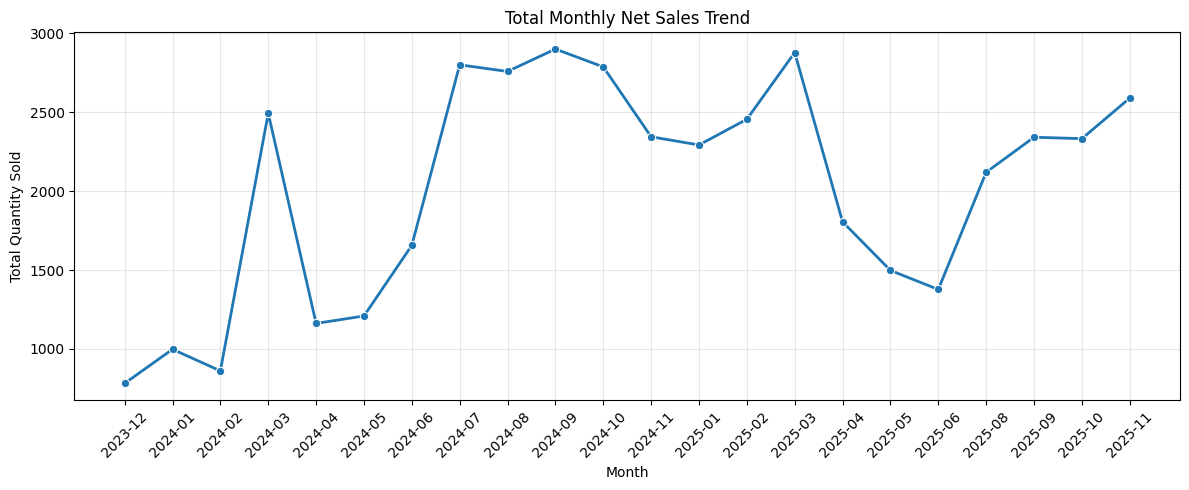

In [20]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_total,
    x='year_month',
    y='Jumlah Terjual Bersih',
    marker='o',
    linewidth=2
)

plt.grid(alpha=0.3)
plt.title('Total Monthly Net Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dari grafik *Monthly Sales Trend* ini, tampak volume penjualan bulanan cenderung berfluktuasi cukup tajam. Beberapa periode menunjukkan spike penjualan yang signifikan kemudian disusul dengan penurunan drastis.

Pola ini mengindikasikan bahwa permintaan tidak bergerak secara linear, melainkan dipengaruhi oleh faktor eksternal tertentu seperti periode promosi, event marketplace, atau momentum musiman.

Indikasi musiman ini cukup tampak pada periode pertengahan 2024 hingga pertengahan 2025, di mana beberapa arah penjualan mengalami kenaikan lalu menurun secara gradual.

Perlu dicatat juga, terdapat *data penjualan yang kosong* pada **Desember 2024** dan **Juli 2025**. Kondisi ini perlu diperhatikan lebih lanjut karena dapat mempengaruhi interpretasi tren penjualan.

Karena grafik penjualan bulanan terlihat cukup fluktuatif, tren pertumbuhan menjadi sulit diamati secara langsung. Oleh karena itu, dilakukan analisis *Month-over-Month* (MoM) Growth untuk melihat perubahan persentase penjualan tiap bulannya.

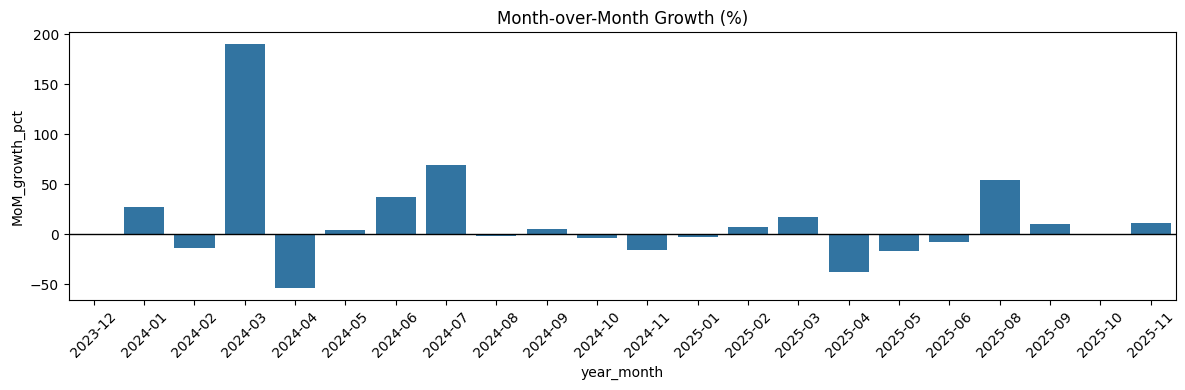

In [21]:
# growth rate
monthly_total['MoM_growth_pct'] = monthly_total['Jumlah Terjual Bersih'].pct_change() * 100

# visualize
plt.figure(figsize=(12,4))

sns.barplot(
    data=monthly_total,
    x='year_month',
    y='MoM_growth_pct'
)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Month-over-Month Growth (%)')
plt.tight_layout()
plt.show()

Visualisasi *MoM growth* menunjukkan bahwa pertumbuhan penjualan bersifat sangat volatil. Beberapa bulan mengalami pertumbuhan yang tinggi, kemudian diikuti dengan penurunan tajam pada bulan berikutnya. Pola ini menunjukkan pertumbuhan demand yang tidak stabil. Permintaan lebih dipengaruhi oleh momentum tertentu, sehingga menyebabkan beberapa kali *spiking* dalam penjualan.

Volatilitas ini sering menjadi indikasi adanya *event-driven demand*, misalnya saat berlangsungnya event promo bulanan besar, diskon musiman, atau masa belanja tertentu di mana transaksi meningkat secara signifikan.

Untuk melihat pola dasar permintaan dengan lebih jelas, dilakukan smoothing menggunakan *rolling 3-month average*. Teknik ini bertujuan untuk meredam fluktuasi jangka pendek sehingga pola permintaan yang lebih stabil dapat terlihat.

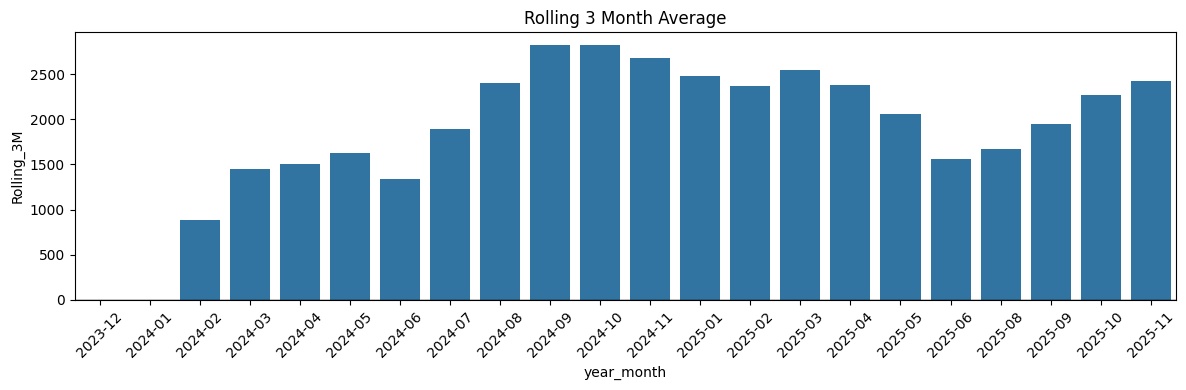

In [22]:
# analyze 3 month average
monthly_total['Rolling_3M'] = monthly_total['Jumlah Terjual Bersih'].rolling(3).mean()

# visualize
plt.figure(figsize=(12,4))

sns.barplot(
    data=monthly_total,
    x='year_month',
    y='Rolling_3M'
)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Rolling 3 Month Average')
plt.tight_layout()
plt.show()

Setelah dilakukan smoothing, ternyata grafik menunjukkan permintaan dengan pola fluktuasi yang relatif konsisten sepanjang waktu.

mengevaluasi seluruh temuan ini, secara umum tidak terlihat adanya tren pertumbuhan jangka panjang yang kuat, meskipun terjadi beberapa kali kenaikan penjualan yang cukup ekstrem sebagaimana dijelaskan di atas.

Dengan kata lain, permintaan cenderung bergerak dalam pola naik-turun yang berulang tanpa menunjukkan peningkatan yang signifikan secara keseluruhan. Lonjakan penjualan yang terjadi pada bulan-bulan tertentu kemungkinan besar dipicu oleh faktor promosi atau event musiman, bukan oleh pertumbuhan permintaan yang berkelanjutan.

## **3. Gross and Net Revenue**

Untuk memahami kontribusi revenue dari masing-masing kategori produk, kita harus membuat kolom *Gross Revenue* (total harga kotor) yang dihitung dari penjumlahan antara kolom `Total Pembayaran`, `Total Diskon`, dan `Ongkos Kirim Dibayar oleh Pembeli`.

In [23]:
# create Gross Revenue column
df['Total Harga'] = df[
    ['Total Pembayaran', 'Total Diskon', 'Ongkos Kirim Dibayar oleh Pembeli']
    ].sum(axis=1)

In [24]:
revenue_summary = (
    df.groupby('Kategori Produk')
      .agg(
          Gross_Revenue=('Total Harga', 'sum'),
          Net_Revenue=('Total Pembayaran', 'sum')
      )
      .sort_values('Gross_Revenue', ascending=False)
      .reset_index()
)

# add cost revenue column
revenue_summary['Cost_Revenue'] = revenue_summary['Gross_Revenue'] - revenue_summary['Net_Revenue']

revenue_summary

,Kategori Produk,Gross_Revenue,Net_Revenue,Cost_Revenue
0,Kitchen & Dining,500416073,423510306,76905767
1,Tools & Accessories,341597616,312981707,28615909
2,Home Organization & Living,292121388,235995143,56126245
3,Food Storage & Packaging,142084703,123602461,18482242
4,Other,74619630,65786412,8833218
5,Bathroom & Cleaning,24229816,18967056,5262760


*Kitchen & Dining* tetap menjadi kontributor pendapatan terbesar dengan gross revenue sekitar 500 juta dan net revenue sekitar 423 juta. Selisih keduanya menunjukkan cost revenue yang cukup besar, hampir 77 juta.

Kategori *Home Organization & Living* menunjukkan selisih yang cukup besar antara gross dan net revenue, yaitu sekitar 56 juta. Walaupun jumlah transaksi kategori ini tinggi, cost yang cukup berat ini menjatuhkan net revenue sehingga menyebabkan berada di bawah *Tools & Accessories*, dimana cost hanya sekitar 29 juta.

Secara keseluruhan, pola ini menunjukkan bahwa produk dengan volume penjualan tinggi akan cenderung mengeluarkan cost yang lebih besar. Hal ini mengindikasikan adanya penggunaan strategi promo diskon dan biaya ongkir yang harus dikeluarkan untuk mendorong volume penjualan top product.

## **4. Weekdays vs Weekend Sales**

Dalam dataset ini kita sudah memiliki kolom `Weekend` yang berisi nilai *Yes* dan *No*. Kita dbisa langsung menggunakannya untuk membandingkan performa penjualan pada hari biasa dan hari libur.

In [25]:
weekend_sales = (
    df.groupby(['Weekend','Kategori Produk'])['Jumlah Terjual Bersih']
      .sum()
      .reset_index()
)

pivot_weekend = weekend_sales.pivot(
    index='Kategori Produk',
    columns='Weekend',
    values='Jumlah Terjual Bersih'
).fillna(0)

<Figure size 1000x600 with 0 Axes>

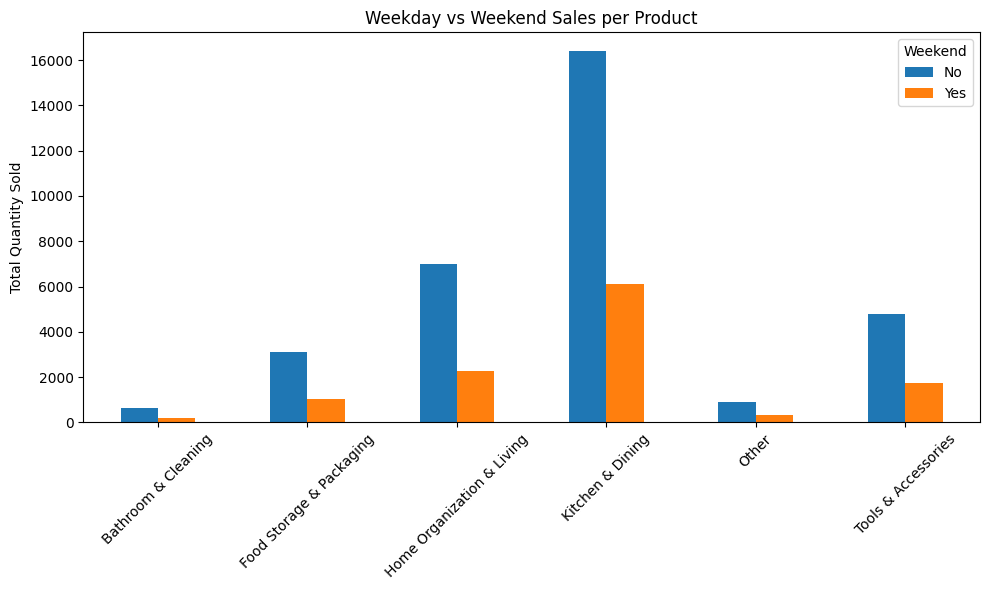

In [26]:
# visualize
plt.figure(figsize=(10,6))

pivot_weekend.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Weekday vs Weekend Sales per Product')
plt.xlabel('')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.legend(title='Weekend')
plt.tight_layout()
plt.show()

Dari grafik terlihat bahwa penjualan pada weekday secara konsisten lebih tinggi dibanding weekend di seluruh kategori produk. Hal ini menunjukkan bahwa sebagian besar transaksi terjadi pada hari kerja, bukan pada hari libur, yang kemungkinan berkaitan dengan perilaku konsumen yang melakukan pembelian secara spontan saat beraktivitas sehari-hari, misalnya ketika membuka marketplace di sela waktu kerja atau aktivitas rutin lainnya.

## **5. Sales by Provinces**

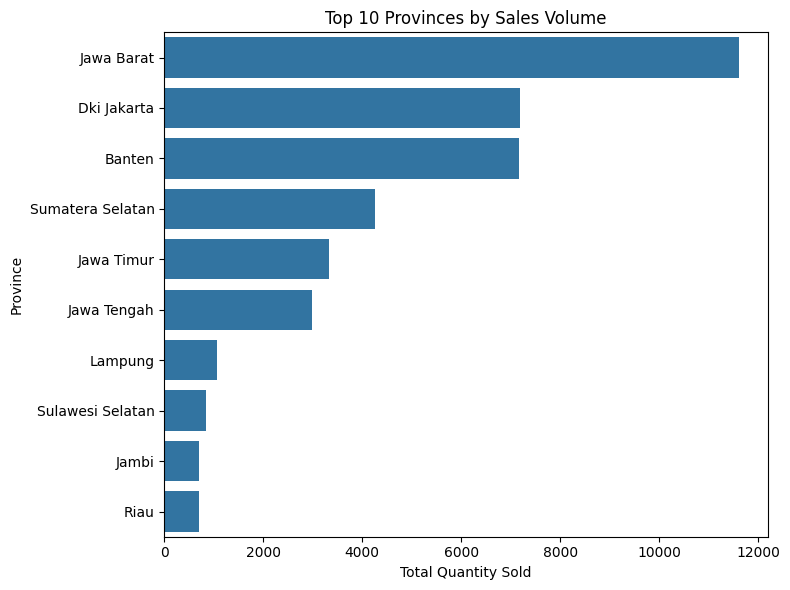

In [27]:
province_sales = (
    df.groupby('Provinsi')['Jumlah']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(8,6))
sns.barplot(
    x=province_sales.values,
    y=province_sales.index
)
plt.title('Top 10 Provinces by Sales Volume')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Province')
plt.tight_layout()
plt.show()

Secara umum, grafik ini menunjukkan bahwa sebagian besar permintaan produk masih terkonsentrasi di Pulau Jawa yan memiliki kepadatan penduduk dan aktivitas ekonomi yang tinggi, serta akses logistik yang baik.

Wilayah dengan volume penjualan tinggi seperti Jawa Barat, DKI Jakarta, dan Banten ini dapat dijadikan sebagai market utama untuk marketing yang lebih agresif, misalnya dengan *marketing campaign*, optimasi *marketplace ads*, atau memastikan stok produk tetap terjaga untuk menghindari kehabisan produk saat momen permintaan tinggi.

Di luar wilayah tersebut, Sumatera Selatan, Jawa Timur, dan Jawa Tengah juga menunjukkan kontribusi penjualan yang cukup signifikan. Sementara itu, provinsi seperti Lampung, Sulawesi Selatan, Jambi, dan Riau memiliki volume penjualan yang lebih kecil, tetapi tetap menunjukkan adanya permintaan dari luar Pulau Jawa.

Salah satu kendala yang menghalangi permintaan pada dearah tersebut adalah biaya logistik yang cenderung lebih mahal dibandingkan Pulau Jawa. Mari kita telusuri di bawah ini.

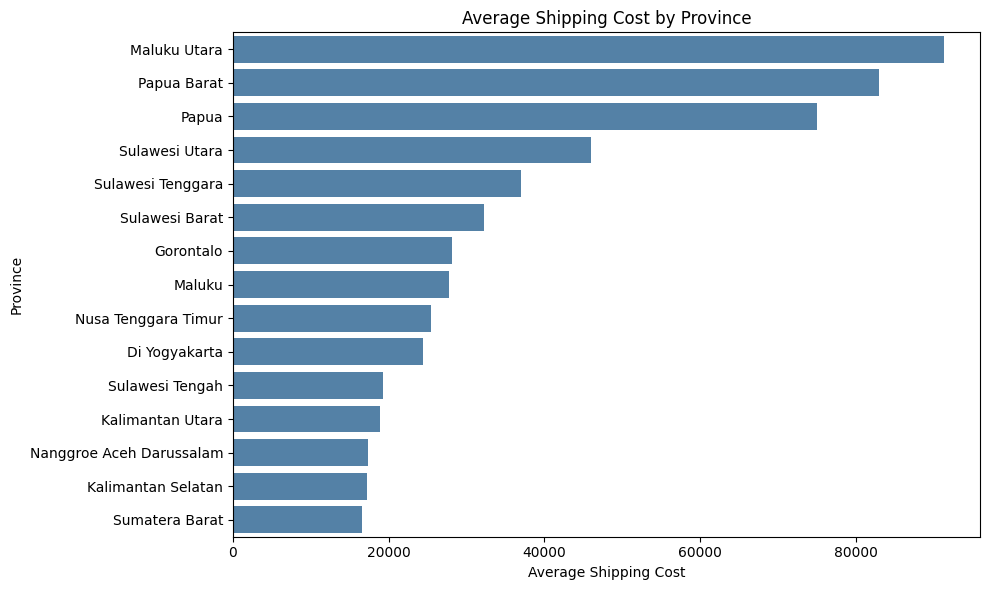

In [28]:
shipping_by_province = (
    df.groupby('Provinsi')['Ongkos Kirim Dibayar oleh Pembeli']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

top_shipping = shipping_by_province.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_shipping,
    x='Ongkos Kirim Dibayar oleh Pembeli',
    y='Provinsi',
    color='steelblue'
)

plt.title('Average Shipping Cost by Province')
plt.xlabel('Average Shipping Cost')
plt.ylabel('Province')
plt.tight_layout()
plt.show()

Dari grafik terlihat bahwa provinsi dengan rata-rata ongkir tertinggi didominasi oleh wilayah Indonesia Timur, seperti Maluku Utara, Papua Barat, dan Papua.

Biaya pengiriman di luar Pulau Jawa yang tinggi menunjukkan bahwa biaya logistik menjadi salah satu faktor yang mempengaruhi distribusi penjualan. Wilayah tersebut mengalami hambatan dari sisi jarak pengiriman dan infrastruktur dan akses distribusi, sehingga menyebabkan ongkir yang melambung tinggi.

Insight ini dapat digunakan sebagai bahan pertimbangan strategi seperti subsidi ongkir atau promo khusus untuk wilayah dengan biaya logistik yang mahal, sehingga dapat membantu meningkatkan daya tarik pembelian di daerah tersebut.

## **6. Payment Methods to Drive Sales and Revenue**

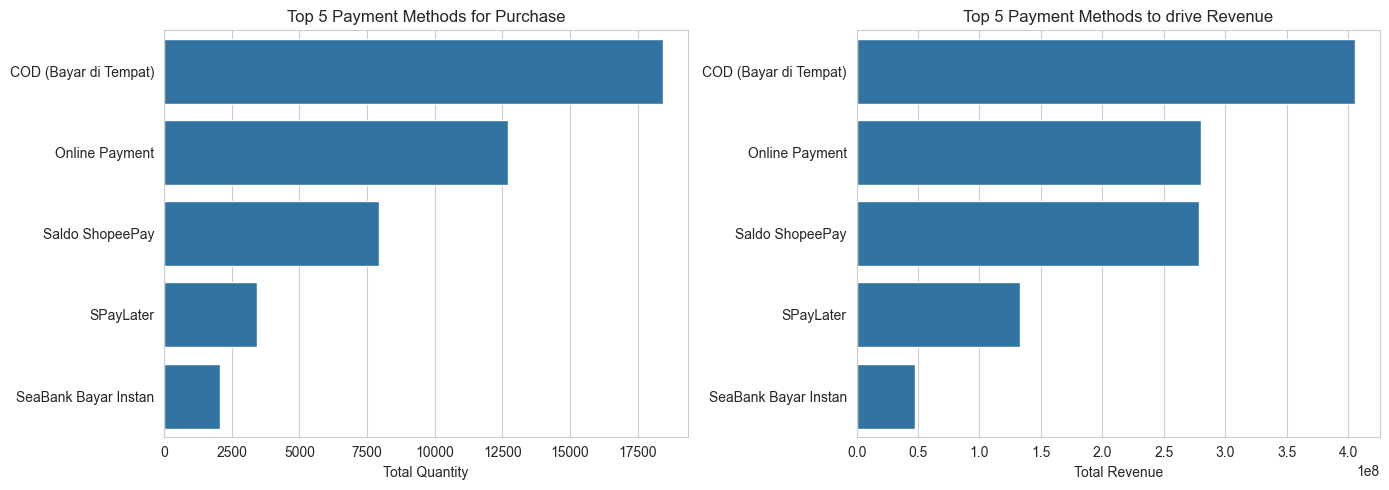

In [29]:
payment_summary = (
    df.groupby('Metode Pembayaran')
      .agg(
          Total_Quantity=('Jumlah', 'sum'),
          Total_Revenue=('Total Pembayaran', 'sum')
      )
      .sort_values('Total_Quantity', ascending=False)
      .head(5)
      .reset_index()
)

sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Plot Quantity
sns.barplot(
    data=payment_summary,
    x='Total_Quantity',
    y='Metode Pembayaran',
    ax=ax[0]
)
ax[0].set_title('Top 5 Payment Methods for Purchase')
ax[0].set_xlabel('Total Quantity')
ax[0].set_ylabel('')

# Plot Revenue
sns.barplot(
    data=payment_summary,
    x='Total_Revenue',
    y='Metode Pembayaran',
    ax=ax[1]
)
ax[1].set_title('Top 5 Payment Methods to drive Revenue')
ax[1].set_xlabel('Total Revenue')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

Berdasarkan temuan sebelumnya, kita tahu bahwa *COD (Bayar di Tempat)* menjadi metode pembayaran paling sering digunakan pembeli, disusul oleh *Online Payment* dan *Saldo ShopeePay*. Hal ini menunjukkan bahwa sebagian besar pembelian masih dilakukan dengan metode pembayaran yang secara langsung saat barang diterima dibandingkan secara digital.

Dan jika dilihat dari sisi `Total Revenue`, grafik menunjukkan bahwa COD tetap menjadi kontributor revenue terbesar, sejalan dengan tingginya volume transaksi yang menggunakan metode ini. Di bawahnya terdapat Online Payment dan ShopeePay yang menghasilkan revenue relatif mirip.

Menariknya, meskipun *SPayLater* memiliki jumlah transaksi yang relatif lebih kecil, kontribusi revenue yang dihasilkan cukup signifikan, hampir setengah dari revenue pada Online Payment dan Saldo ShoopePay.

Hal ini mengindikasikan bahwa transaksi yang menggunakan metode cicilan kemungkinan memiliki nilai pembelian yang lebih tinggi dibanding metode pembayaran lainnya.

## **7. Product Return Rate**

In [30]:
return_rate = (
    df.groupby('Kategori Produk')
      .agg({
          'Jumlah':'sum',
          'Returned Quantity':'sum'
      })
)

return_rate['Return Rate %'] = (
    return_rate['Returned Quantity'] /
    return_rate['Jumlah'] * 100
).round(2)

return_rate.sort_values('Return Rate %', ascending=False)

,Jumlah,Returned Quantity,Return Rate %
Kategori Produk,,,
Food Storage & Packaging,4460,357,8.00
Other,1225,34,2.78
Bathroom & Cleaning,881,18,2.04
Home Organization & Living,9431,173,1.83
Kitchen & Dining,22848,322,1.41
Tools & Accessories,6561,51,0.78


Analisis ini menunjukkan bahwa tingkat retur barang secara keseluruhan relatif rendah di hampir semua kategori. Sebagian besar berada di bawah 3%. Hal ini mengindikasikan bahwa mayoritas transaksi berakhir dengan produk yang tetap dipertahankan oleh pembeli tanpa proses pengembalian.

Produk dengan angka retur tertinggi adalah *Food Storage & Packaging* dengan tingkat retur sekitar 8%. Angka ini cukup tinggi dibandingkan yang lain, mengindikasikan adanya potensi masalah pada kategori tersebut, seperti ekspektasi kualitas yang tidak terpenuhi.

Produk ini perlu mendapatkan perhatian khusus untuk evaluasi kualitas produk, deskripsi barang, atau standar pengemasan untuk menurunkan angka retur untuk meningkatkan nilai kepuasan konsumen.

## **8. Order Cancellation Rate**

In [31]:
cancel_summary = (
    df.groupby('Kategori Produk')
      .agg(
          total_orders=('Status Pesanan', 'count'),
          total_cancel=('Status Pesanan', lambda x: (x == 'Batal').sum())
      )
)

cancel_summary['cancel_rate_pct'] = (
    cancel_summary['total_cancel'] / cancel_summary['total_orders'] * 100
)

cancel_summary = cancel_summary.sort_values('cancel_rate_pct', ascending=False)
cancel_summary

,total_orders,total_cancel,cancel_rate_pct
Kategori Produk,,,
Food Storage & Packaging,1733,310,17.888055
Other,853,151,17.702227
Bathroom & Cleaning,521,78,14.971209
Kitchen & Dining,7872,1084,13.770325
Home Organization & Living,7152,964,13.478747
Tools & Accessories,3452,362,10.486674


Tingkat pembatalan pesanan menunjukkan angka yang relatif konsisten di seluruh kategori produk di kisaran 10% hingga 18%. Hal ini menunjukkan bahwa pembatalan pesanan bukan merupakan masalah yang spesifik pada satu kategori tertentu, melainkan pola yang cukup umum terjadi di berbagai jenis produk.

Karena perbedaan antar kategori relatif kecil, hal ini menunjukkan bahwa pembatalan pesanan kemungkinan lebih dipengaruhi oleh perilaku pembeli atau proses transaksi, bukan oleh karakteristik produk tertentu. Mari kita telusuri lebih lanjut dengan melihat kolom `Alasan Pembatalan`.

In [32]:
top_cancel_reasons = (
    df[df['Status Pesanan'] == 'Batal']['Alasan Pembatalan']
      .value_counts()
      .head(5)
      .reset_index()
)

top_cancel_reasons.columns = ['Alasan Pembatalan', 'Jumlah']
top_cancel_reasons

,Alasan Pembatalan,Jumlah
0,Lainnya/ berubah pikiran,636
1,Ubah Pesanan yang Ada,581
2,Lainnya,527
3,Perlu mengubah alamat pengiriman,439
4,Pengiriman gagal,262


Hasilnya menunjukkan bahwa bahwa mayoritas pembatalan pesanan tidak disebabkan oleh masalah produk, melainkan lebih berkaitan dengan perubahan keputusan pembeli setelah melakukan checkout atau penyesuaian terkait proses pengiriman, seperti berubah pikiran, mengubah pesanan yang sudah dibuat, atau alasan umum lainnya.

Selain itu, terdapat juga pembatalan yang disebabkan oleh faktor operasional seperti perlu mengubah alamat pengiriman serta pengiriman gagal, meskipun jumlahnya lebih kecil dibanding alasan yang berasal dari sisi pembeli.

---

# **Executive Summary**

Analisis ini bertujuan untuk memahami pola permintaan, faktor pendorong penjualan, serta beberapa aspek operasional yang mempengaruhi performa penjualan dalam dataset. Dengan mengeksplorasi distribusi produk, tren penjualan bulanan, perilaku pembelian konsumen, hingga faktor logistik dan operasional, analisis ini memberikan gambaran menyeluruh mengenai dinamika penjualan yang terjadi.

## **Key Findings**

1. Penjualan terkonsentrasi pada beberapa kategori utama, terutama Kitchen & Dining dan Home Organization & Living yang menyumbang mayoritas transaksi.

2. Permintaan bersifat fluktuatif dan cenderung dipengaruhi oleh momentum tertentu, seperti event promosi atau periode belanja musiman.

3. Metode pembayaran COD masih mendominasi transaksi, meskipun metode pembayaran digital mulai menunjukkan kontribusi pendapatan yang signifikan.

4. Biaya logistik menjadi faktor penting dalam distribusi penjualan, dengan wilayah di luar Pulau Jawa memiliki ongkir yang jauh lebih tinggi.

5. Aktivitas pembelian lebih banyak terjadi pada hari kerja, menunjukkan pola belanja yang berkaitan dengan rutinitas harian konsumen.

6. Tingkat return produk relatif rendah, yang menunjukkan bahwa sebagian besar produk sesuai dengan ekspektasi pembeli.

7. Pembatalan pesanan lebih banyak dipicu oleh keputusan pembeli, bukan oleh masalah produk atau operasional.

## **1. Demand Overview**

Secara umum, penjualan dalam dataset didominasi oleh beberapa kategori produk utama. Kitchen & Dining dan Home Organization & Living menyumbang hampir 70% dari total transaksi, menjadikannya kontributor utama terhadap volume penjualan. Kategori Tools & Accessories juga memberikan kontribusi yang cukup signifikan, sementara kategori lainnya memiliki porsi penjualan yang lebih kecil.

Dari sisi geografis, sebagian besar penjualan terkonsentrasi di provinsi-provinsi dengan populasi tinggi dan akses logistik yang baik, khususnya di wilayah Pulau Jawa seperti Jawa Barat, DKI Jakarta, dan Banten. Hal ini menunjukkan bahwa permintaan produk sangat dipengaruhi oleh kepadatan populasi serta kemudahan distribusi logistik.

## **2. Demand Patern**

Analisis tren penjualan bulanan menunjukkan bahwa permintaan cenderung fluktuatif dari waktu ke waktu. Beberapa periode menunjukkan lonjakan penjualan yang cukup tinggi, namun sering diikuti dengan penurunan tajam pada bulan berikutnya. Hal ini terlihat jelas pada analisis Month-over-Month growth, yang menunjukkan adanya spike pertumbuhan yang ekstrem di beberapa bulan.

Setelah dilakukan smoothing menggunakan rolling 3-month average, pola permintaan terlihat lebih stabil dan menunjukkan adanya indikasi seasonality dalam penjualan. Meskipun terdapat lonjakan penjualan pada bulan tertentu, secara keseluruhan tidak terlihat tren pertumbuhan jangka panjang yang konsisten. Hal ini mengindikasikan bahwa permintaan kemungkinan dipengaruhi oleh event promosi atau momentum belanja tertentu.

## **3. Demand Drivers**

Beberapa faktor yang berpotensi mempengaruhi permintaan dapat diidentifikasi dari perilaku transaksi dalam dataset.

Dari sisi metode pembayaran, COD (Bayar di Tempat) masih menjadi metode pembayaran yang paling dominan baik dari sisi jumlah transaksi maupun kontribusi revenue. Namun metode pembayaran digital seperti Online Payment dan ShopeePay juga memberikan kontribusi pendapatan yang cukup besar. Selain itu, metode cicilan seperti SPayLater menunjukkan indikasi menghasilkan nilai transaksi yang relatif lebih tinggi meskipun jumlah penggunaannya lebih sedikit.

Faktor logistik juga berperan dalam distribusi penjualan antar wilayah. Analisis ongkos kirim menunjukkan bahwa wilayah di luar Pulau Jawa, seperti Papua dan Maluku, memiliki biaya pengiriman yang jauh lebih tinggi dibanding wilayah lainnya. Kondisi ini berpotensi menjadi hambatan bagi aktivitas e-commerce di daerah tersebut.

Dari sisi waktu transaksi, penjualan cenderung lebih tinggi pada hari kerja dibanding akhir pekan. Hal ini menunjukkan bahwa aktivitas pembelian kemungkinan besar dilakukan selama rutinitas harian, misalnya ketika konsumen membuka marketplace di sela aktivitas kerja.

## **4. Operational Factors**

Selain faktor permintaan, beberapa aspek operasional juga dianalisis untuk melihat potensi hambatan dalam proses transaksi.

Tingkat pengembalian produk (return rate) secara keseluruhan relatif rendah di hampir semua kategori produk, yang menunjukkan bahwa sebagian besar produk diterima dengan baik oleh pembeli. Namun kategori Food Storage & Packaging memiliki return rate yang sedikit lebih tinggi dibanding kategori lainnya sehingga dapat menjadi area yang perlu dievaluasi lebih lanjut.

Sementara itu, order cancellation rate menunjukkan pola yang relatif konsisten di seluruh kategori produk dengan kisaran sekitar 10–18%. Analisis alasan pembatalan menunjukkan bahwa sebagian besar pembatalan terjadi karena faktor dari sisi pembeli, seperti perubahan keputusan atau modifikasi pesanan, sementara faktor operasional seperti kegagalan pengiriman hanya menyumbang sebagian kecil dari total pembatalan.

## **Business Recommendations**

Berdasarkan keseluruhan hasil analisis, terdapat beberapa strategi bisnis yang dapat dipertimbangkan untuk meningkatkan penjualan sekaligus memperbaiki efisiensi operasional.

1. Fokus pada Kategori Produk dengan Permintaan Tinggi

    Kategori Kitchen & Dining serta Home Organization & Living merupakan kontributor utama terhadap volume penjualan dan revenue. Oleh karena itu, kedua kategori ini dapat dijadikan sebagai core product line dalam strategi bisnis.

    Beberapa langkah yang dapat dilakukan antara lain meningkatkan ketersediaan stok pada kategori tersebut, memperluas variasi produk yang masih relevan dengan kebutuhan rumah tangga, serta memanfaatkan kategori ini sebagai produk utama dalam kampanye promosi. Dengan memaksimalkan kategori yang sudah memiliki permintaan tinggi, perusahaan dapat meningkatkan penjualan tanpa harus membangun permintaan dari nol.

2. Memanfaatkan Momentum Promosi untuk Mengoptimalkan Lonjakan Penjualan

    Analisis tren bulanan menunjukkan bahwa penjualan sering mengalami lonjakan pada periode tertentu dan kemudian turun kembali pada bulan berikutnya. Pola ini mengindikasikan bahwa penjualan kemungkinan dipengaruhi oleh event-driven demand, seperti kampanye promosi marketplace atau periode belanja tertentu.

    Strategi yang dapat diterapkan adalah menyelaraskan aktivitas pemasaran dengan momentum tersebut, misalnya dengan memberikan promo tambahan pada periode kampanye besar, meningkatkan eksposur produk saat event belanja berlangsung, serta memastikan ketersediaan stok sebelum periode promosi dimulai.

3. Mendorong Adopsi Metode Pembayaran Digital

    Walaupun COD masih mendominasi transaksi, metode pembayaran digital seperti Online Payment dan ShopeePay sudah menunjukkan kontribusi revenue yang cukup besar. Selain itu, metode cicilan seperti SPayLater juga berpotensi menghasilkan nilai transaksi yang lebih tinggi.

    Perusahaan dapat mendorong penggunaan metode pembayaran digital melalui program cashback, diskon tambahan, atau promosi eksklusif untuk metode pembayaran tertentu. Selain mempercepat proses transaksi, strategi ini juga dapat membantu mengurangi risiko pembatalan pesanan yang sering terjadi pada transaksi COD.

4. Mengoptimalkan Strategi Logistik untuk Wilayah di Luar Pulau Jawa

    Analisis ongkos kirim menunjukkan bahwa wilayah di luar Pulau Jawa memiliki biaya logistik yang jauh lebih tinggi dibanding wilayah lain. Hal ini berpotensi menjadi hambatan bagi pembeli untuk melakukan transaksi.

    Salah satu strategi yang dapat dipertimbangkan adalah memberikan subsidi ongkir atau promosi khusus untuk wilayah dengan biaya pengiriman tinggi, terutama pada periode promosi tertentu. Alternatif lainnya adalah mempertimbangkan kerja sama logistik yang lebih efisien atau sistem distribusi yang dapat menekan biaya pengiriman ke wilayah tersebut.

5. Mengurangi Return Rate pada Kategori dengan Risiko Lebih Tinggi

    Walaupun tingkat pengembalian produk secara keseluruhan relatif rendah, kategori Food Storage & Packaging menunjukkan return rate yang lebih tinggi dibanding kategori lainnya. Hal ini dapat menjadi indikasi adanya ketidaksesuaian antara produk yang diterima dan ekspektasi pembeli.

    Perbaikan dapat dilakukan melalui peningkatan deskripsi produk, foto produk yang lebih jelas, serta informasi spesifikasi yang lebih detail. Dengan memberikan informasi produk yang lebih akurat, risiko kesalahan pembelian dapat dikurangi sehingga tingkat pengembalian produk dapat ditekan.

6. Mengurangi Pembatalan Pesanan Melalui Perbaikan Proses Checkout

    Sebagian besar pembatalan pesanan berasal dari keputusan pembeli, seperti perubahan pesanan atau perubahan alamat pengiriman. Hal ini menunjukkan bahwa proses checkout mungkin masih memungkinkan pembeli untuk membatalkan pesanan setelah transaksi dibuat.

    Untuk mengurangi hal ini, perusahaan dapat menerapkan fitur seperti konfirmasi pesanan sebelum checkout selesai, batas waktu perubahan alamat, atau pengingat pembayaran otomatis. Langkah ini dapat membantu menekan tingkat pembatalan pesanan tanpa mengganggu pengalaman belanja pembeli.

Strategi bisnis yang disarankan berfokus pada tiga aspek utama: memaksimalkan kategori dengan permintaan tinggi, mengoptimalkan strategi promosi dan pembayaran, serta meningkatkan efisiensi operasional dalam logistik dan proses transaksi. Dengan memanfaatkan insight dari data penjualan yang ada, perusahaan dapat mengambil keputusan yang lebih terarah untuk meningkatkan performa bisnis secara berkelanjutan.

---

# **Saving final `df` version to .csv file for dashboard**

In [33]:
df.to_csv('dataset/data_dashboard.csv', index=False)

---